In [1]:
!pip install -q torch torchvision imbalanced-learn plotly scikit-learn shap

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# SMOTE
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.1)

SEV_MAP    = {0:'None', 1:'Mild', 2:'Moderate', 3:'Severe'}
SEV_ORDER  = ['None','Mild','Moderate','Severe']
SEV_COLORS = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
RANDOM_STATE = 42
N_CLASSES    = 4

# Reproducibility
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'TensorFlow version : {tf.__version__}')
print(f'PyTorch version    : {torch.__version__}')
print(f'GPU available      : {torch.cuda.is_available()}')
print(f'PyTorch device     : {DEVICE}')
print(f'Keras backend      : {tf.keras.backend.backend()}')

TensorFlow version : 2.19.0
PyTorch version    : 2.10.0+cpu
GPU available      : False
PyTorch device     : cpu
Keras backend      : tensorflow


In [4]:
def find_file(root, filename):
    for dirpath, dirs, files in os.walk(root):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

DRIVE_ROOT = '/content/drive/MyDrive'
PATH_FEATS = find_file(DRIVE_ROOT, 'ddi_nigeria_features.csv')

print(f'ddi_nigeria_features.csv : {PATH_FEATS or "NOT FOUND"}')

# Manual override:
# PATH_FEATS = '/content/drive/MyDrive/YOUR_FOLDER/ddi_nigeria_features.csv'

if PATH_FEATS is None:
    raise FileNotFoundError('Run Notebook 01 first to generate ddi_nigeria_features.csv')

SAVE_FOLDER   = os.path.dirname(PATH_FEATS)
MODELS_FOLDER = os.path.join(SAVE_FOLDER, 'models')
os.makedirs(MODELS_FOLDER, exist_ok=True)

print(f'Save folder: {SAVE_FOLDER}')

ddi_nigeria_features.csv : /content/drive/MyDrive/DDI project /ddi_nigeria_features.csv
Save folder: /content/drive/MyDrive/DDI project 


In [5]:
df = pd.read_csv(PATH_FEATS)
print(f'Dataset shape  : {df.shape}')
print(f'Severity dist  :')
print(df['severity_label'].value_counts())
df.head()

Dataset shape  : (50, 37)
Severity dist  :
severity_label
Moderate    28
Severe      11
Mild         7
Name: count, dtype: int64


,drug_a,drug_b,class_a,class_b,severity,mw_a,mw_b,logp_a,logp_b,tpsa_a,tpsa_b,hbond_donors_a,hbond_donors_b,hbond_acceptors_a,hbond_acceptors_b,cyp3a4_inhibitor_a,cyp3a4_inducer_a,cyp2c9_inhibitor_a,cyp2c9_substrate_a,narrow_ti_a,protein_binding_a,half_life_a,cyp3a4_inhibitor_b,cyp3a4_inducer_b,cyp2c9_inhibitor_b,cyp2c9_substrate_b,narrow_ti_b,protein_binding_b,half_life_b,same_class,metabolic_conflict,inducer_substrate_conflict,both_narrow_ti,both_high_protein_binding,class_a_enc,class_b_enc,severity_label
0,rifampicin,efavirenz,Anti_TB,Antiretrovirals,2,822.9,315.67,4.9,4.0,220.0,38.3,6,1,15,5,0,1,0,0,0,80.0,3.0,1,1,0,0,0,99.0,52.0,0,0,0,0,0,1,8,Moderate
1,rifampicin,nevirapine,Anti_TB,Antiretrovirals,2,822.9,266.30,4.9,2.0,220.0,58.1,6,1,15,4,0,1,0,0,0,80.0,3.0,0,1,0,0,0,60.0,25.0,0,0,0,0,0,1,8,Moderate
2,rifampicin,lopinavir,Anti_TB,Antiretrovirals,3,822.9,628.80,4.9,5.9,220.0,120.0,6,4,15,5,0,1,0,0,0,80.0,3.0,0,0,0,0,0,99.0,6.0,0,0,1,0,0,1,8,Severe
3,rifampicin,dolutegravir,Anti_TB,Antiretrovirals,2,822.9,419.40,4.9,2.4,220.0,99.2,6,2,15,8,0,1,0,0,0,80.0,3.0,0,0,0,0,0,99.0,14.0,0,0,1,0,0,1,8,Moderate
4,rifampicin,warfarin,Anti_TB,Anticoagulants,3,822.9,308.30,4.9,2.7,220.0,63.6,6,1,15,4,0,1,0,0,0,80.0,3.0,0,0,0,1,1,99.0,40.0,0,0,0,0,0,1,3,Severe


In [6]:
DROP_COLS = ['drug_a','drug_b','class_a','class_b','severity_label',
             'side_effect_name','source','Drug1_ID','Drug2_ID','Drug1','Drug2','Y']

FEATURE_COLS = [c for c in df.columns
                if c not in DROP_COLS + ['severity','class_a_enc','class_b_enc']
                and df[c].dtype in ['float64','int64','float32','int32']]

for enc in ['class_a_enc','class_b_enc']:
    if enc in df.columns and enc not in FEATURE_COLS:
        FEATURE_COLS.append(enc)

TARGET_COL = 'severity'
N_FEATURES = len(FEATURE_COLS)

print(f'Feature columns : {N_FEATURES}')
print(f'Target          : {TARGET_COL}')

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Impute
imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=FEATURE_COLS)

# Train/test split
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# SMOTE
min_count = y_train_raw.value_counts().min()
k_nb      = min(5, min_count - 1)
smote     = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_nb)
X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train_raw)

# Scale — essential for DNNs
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f'\nAfter SMOTE + scaling:')
print(f'  Train: {X_train_sc.shape}')
print(f'  Test : {X_test_sc.shape}')
for cls, name in SEV_MAP.items():
    n = (y_train_sm == cls).sum()
    print(f'  {name:10s}: {n:,}')

Feature columns : 31
Target          : severity

After SMOTE + scaling:
  Train: (88, 31)
  Test : (10, 31)
  None      : 22
  Mild      : 22
  Moderate  : 22
  Severe    : 22


In [7]:
# Further split train into train + validation (for DNN training curves)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sc, y_train_sm,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train_sm
)

print(f'Train   : {X_tr.shape}')
print(f'Val     : {X_val.shape}')
print(f'Test    : {X_test_sc.shape}')

Train   : (74, 31)
Val     : (14, 31)
Test    : (10, 31)


In [8]:
def build_keras_dnn(n_features, n_classes=4, dropout_rates=(0.3, 0.25, 0.2)):
    """
    Feedforward DNN for multi-class DDI severity classification.
    Uses BatchNormalization for training stability and Dropout for regularisation.
    """
    inputs = keras.Input(shape=(n_features,), name='features')

    # Block 1
    x = layers.Dense(256, name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(dropout_rates[0], name='drop_1')(x)

    # Block 2
    x = layers.Dense(128, name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(dropout_rates[1], name='drop_2')(x)

    # Block 3
    x = layers.Dense(64, name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Dropout(dropout_rates[2], name='drop_3')(x)

    # Output
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='DDI_Keras_DNN')
    return model

keras_model = build_keras_dnn(n_features=N_FEATURES)
keras_model.summary()

Model: "DDI_Keras_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,396 (200.77 KB)

 Trainable params: 50,500 (197.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
# Compile
keras_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# Compute class weights for loss weighting
from sklearn.utils.class_weight import compute_class_weight
cls_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_tr),
    y=y_tr
)
class_weight_dict = dict(enumerate(cls_weights))
print('Class weights:', {SEV_MAP[k]: round(v,3) for k,v in class_weight_dict.items()})

# Callbacks
KERAS_CKPT = os.path.join(MODELS_FOLDER, 'keras_dnn_best.h5')

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        KERAS_CKPT, monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

print('Model compiled. Ready to train.')

Class weights: {'None': np.float64(1.028), 'Mild': np.float64(0.974), 'Moderate': np.float64(1.028), 'Severe': np.float64(0.974)}
Model compiled. Ready to train.


In [10]:
print('Training Keras DNN...')
keras_history = keras_model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = 150,
    batch_size      = 64,
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1
)

best_epoch = np.argmin(keras_history.history['val_loss']) + 1
print(f'\nTraining complete.')
print(f'  Best epoch      : {best_epoch}')
print(f'  Best val_loss   : {min(keras_history.history["val_loss"]):.4f}')
print(f'  Best val_acc    : {keras_history.history["val_accuracy"][best_epoch-1]:.4f}')

Training Keras DNN...
Epoch 1/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 13s 14s/step - accuracy: 0.3125 - loss: 1.8231

2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3514 - loss: 1.7473 - val_accuracy: 0.2857 - val_loss: 1.3436 - learning_rate: 0.0010
Epoch 2/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2969 - loss: 1.6551

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 456ms/step - accuracy: 0.3784 - loss: 1.5458 - val_accuracy: 0.5714 - val_loss: 1.2753 - learning_rate: 0.0010
Epoch 3/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5156 - loss: 1.3453

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step - accuracy: 0.5541 - loss: 1.2773 - val_accuracy: 0.7143 - val_loss: 1.2136 - learning_rate: 0.0010
Epoch 4/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.6406 - loss: 1.0360

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 976ms/step - accuracy: 0.6622 - loss: 0.9885 - val_accuracy: 0.7143 - val_loss: 1.1662 - learning_rate: 0.0010
Epoch 5/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6562 - loss: 0.8291

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9730 - loss: 0.0890 - val_accuracy: 0.9286 - val_loss: 0.2942 - learning_rate: 0.0010
Epoch 93/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9844 - loss: 0.1431

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9865 - loss: 0.1259 - val_accuracy: 0.9286 - val_loss: 0.2930 - learning_rate: 0.0010
Epoch 94/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9844 - loss: 0.0882

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9865 - loss: 0.0832 - val_accuracy: 0.9286 - val_loss: 0.2913 - learning_rate: 0.0010
Epoch 95/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9844 - loss: 0.0876

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9865 - loss: 0.0828 - val_accuracy: 0.9286 - val_loss: 0.2902 - learning_rate: 0.0010
Epoch 96/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9865 - loss: 0.0800 - val_accuracy: 0.9286 - val_loss: 0.2906 - learning_rate: 0.0010
Epoch 97/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9865 - loss: 0.0655 - val_accuracy: 0.9286 - val_loss: 0.2909 - learning_rate: 0.0010
Epoch 98/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 1.0000 - loss: 0.0534 - val_accuracy: 0.9286 - val_loss: 0.2903 - learning_rate: 0.0010
Epoch 99/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9844 - loss: 0.0778

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9865 - loss: 0.0719 - val_accuracy: 0.9286 - val_loss: 0.2901 - learning_rate: 0.0010
Epoch 100/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9865 - loss: 0.0680 - val_accuracy: 0.9286 - val_loss: 0.2906 - learning_rate: 0.0010
Epoch 101/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9865 - loss: 0.0513 - val_accuracy: 0.9286 - val_loss: 0.2909 - learning_rate: 0.0010
Epoch 102/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.0522 - val_accuracy: 0.9286 - val_loss: 0.2916 - learning_rate: 0.0010
Epoch 103/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0374 - val_accuracy: 0.9286 - val_loss: 0.2924 - learning_rate: 0.0010
Epoch 104/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 0.0431 - val_accuracy: 0.9286 - val_loss: 0.2934 - learning_rate: 0.0010
Epoch 105/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9865 - loss: 0.0497 - val_accuracy:

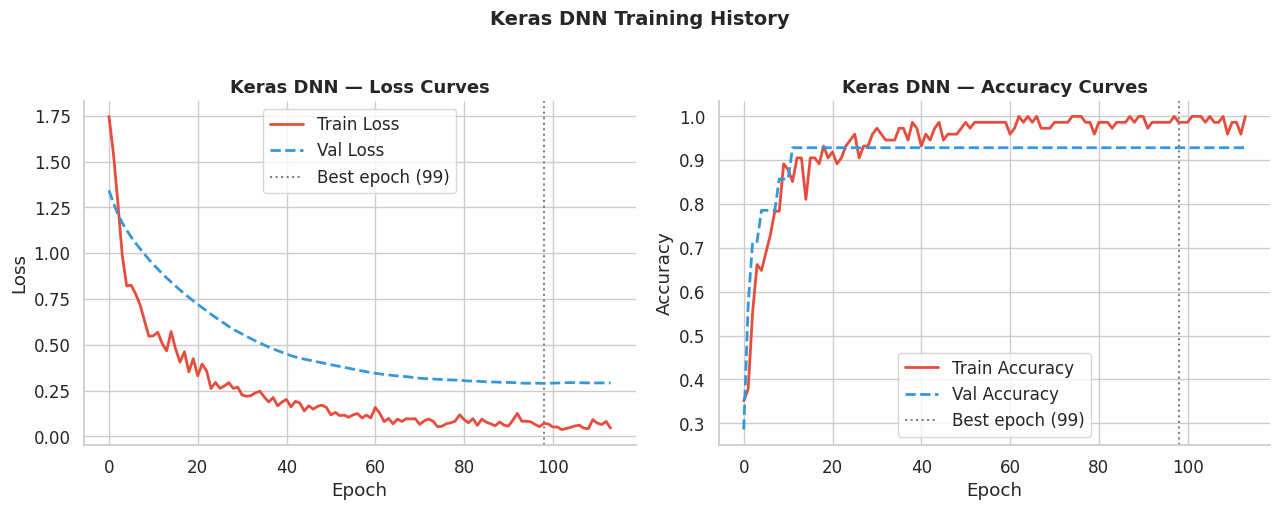

In [11]:
# Training curves
hist = keras_history.history
epochs_ran = len(hist['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Loss
ax1.plot(hist['loss'],     color='#e74c3c', lw=2, label='Train Loss')
ax1.plot(hist['val_loss'], color='#3498db', lw=2, label='Val Loss', linestyle='--')
ax1.axvline(best_epoch-1, color='gray', linestyle=':', lw=1.5, label=f'Best epoch ({best_epoch})')
ax1.set_title('Keras DNN — Loss Curves', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.spines[['top','right']].set_visible(False)

# Accuracy
ax2.plot(hist['accuracy'],     color='#e74c3c', lw=2, label='Train Accuracy')
ax2.plot(hist['val_accuracy'], color='#3498db', lw=2, label='Val Accuracy', linestyle='--')
ax2.axvline(best_epoch-1, color='gray', linestyle=':', lw=1.5, label=f'Best epoch ({best_epoch})')
ax2.set_title('Keras DNN — Accuracy Curves', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Keras DNN Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('keras_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
keras_proba = keras_model.predict(X_test_sc, verbose=0)
keras_preds = np.argmax(keras_proba, axis=1)

keras_f1  = f1_score(y_test, keras_preds, average='macro')
keras_auc = roc_auc_score(
    label_binarize(y_test, classes=[0,1,2,3]),
    keras_proba, multi_class='ovr', average='macro'
)

print('Keras DNN Results:')
print(f'  Macro F1  : {keras_f1:.4f}')
print(f'  ROC-AUC   : {keras_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, keras_preds,
      target_names=SEV_ORDER, digits=4))

Keras DNN Results:
  Macro F1  : 0.1500
  ROC-AUC   : 0.5156

Classification Report:
              precision    recall  f1-score   support

        None     0.0000    0.0000    0.0000         1
        Mild     0.0000    0.0000    0.0000         1
    Moderate     0.7500    0.5000    0.6000         6
      Severe     0.0000    0.0000    0.0000         2

    accuracy                         0.3000        10
   macro avg     0.1875    0.1250    0.1500        10
weighted avg     0.4500    0.3000    0.3600        10



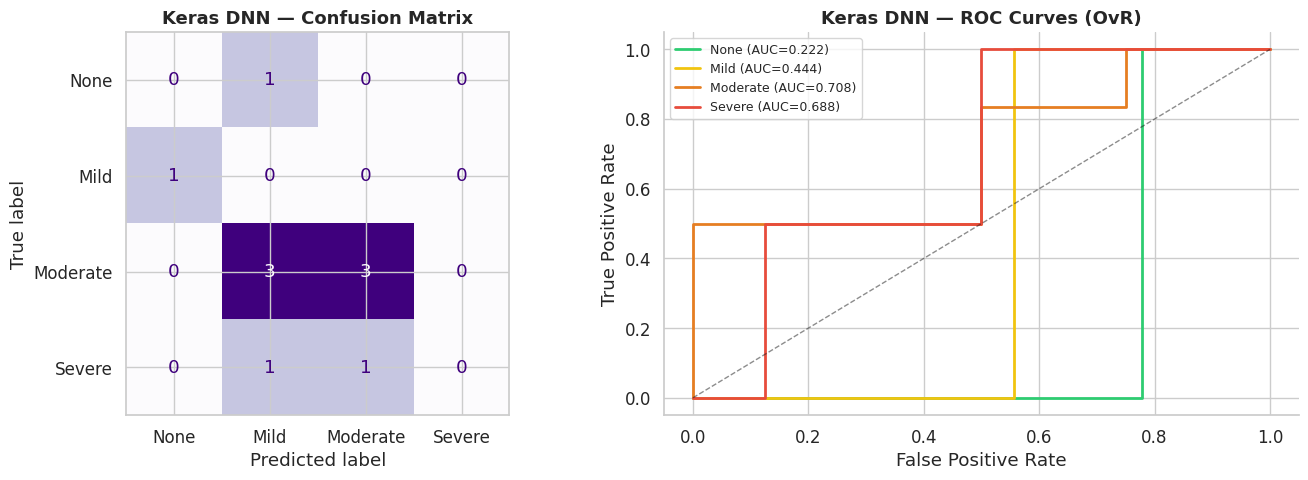

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, keras_preds),
    display_labels=SEV_ORDER).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Keras DNN — Confusion Matrix', fontsize=13, fontweight='bold')

# ROC curves overlaid on one plot
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
for i, (cls_name, color) in enumerate(zip(SEV_ORDER, SEV_COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], keras_proba[:,i])
    roc_val     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC={roc_val:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_title('Keras DNN — ROC Curves (OvR)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('keras_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
class DDIClassifier(nn.Module):
    """
    PyTorch DNN for DDI severity classification.
    Architecture mirrors the Keras model:
    Input -> Dense(256) -> BN -> ReLU -> Dropout
           -> Dense(128) -> BN -> ReLU -> Dropout
           -> Dense(64)  -> BN -> ReLU -> Dropout
           -> Dense(4) -> Softmax
    """
    def __init__(self, n_features, n_classes=4,
                 dropout_rates=(0.3, 0.25, 0.2)):
        super(DDIClassifier, self).__init__()

        self.block1 = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rates[0])
        )
        self.block2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rates[1])
        )
        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rates[2])
        )
        self.output = nn.Linear(64, n_classes)

        # Weight initialisation — He init for ReLU networks
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.output(x)  # raw logits — CrossEntropyLoss handles softmax

pt_model = DDIClassifier(n_features=N_FEATURES, n_classes=N_CLASSES).to(DEVICE)
print(pt_model)
total_params = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

DDIClassifier(
  (block1): Sequential(
    (0): Linear(in_features=31, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=64, out_features=4, bias=True)
)

Trainable parameters: 50,500


In [15]:
# DataLoaders
def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.values if hasattr(y,'values') else y, dtype=torch.long)
    ds  = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_tr,      y_tr,  batch_size=64, shuffle=True)
val_loader   = make_loader(X_val,     y_val, batch_size=128, shuffle=False)
test_loader  = make_loader(X_test_sc, y_test, batch_size=128, shuffle=False)

# Class weights for CrossEntropyLoss
from sklearn.utils.class_weight import compute_class_weight
cls_w  = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
cls_wt = torch.tensor(cls_w, dtype=torch.float32).to(DEVICE)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=cls_wt)
optimizer = optim.Adam(pt_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Class weights : {dict(zip(SEV_ORDER, [round(w,3) for w in cls_w]))}')

Train batches : 2
Val batches   : 1
Class weights : {'None': np.float64(1.028), 'Mild': np.float64(0.974), 'Moderate': np.float64(1.028), 'Severe': np.float64(0.974)}


In [16]:
# Custom training loop
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits  = model(X_batch)
            loss    = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


print('Training functions defined.')

Training functions defined.


In [17]:
print('Training Keras DNN...')
keras_history = keras_model.fit(
    X_tr, y_tr,
    validation_data = (X_val, y_val),
    epochs          = 150,
    batch_size      = 64,
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1
)

best_epoch = np.argmin(keras_history.history['val_loss']) + 1
print(f'\nTraining complete.')
print(f'  Best epoch      : {best_epoch}')
print(f'  Best val_loss   : {min(keras_history.history["val_loss"]):.4f}')
print(f'  Best val_acc    : {keras_history.history["val_accuracy"][best_epoch-1]:.4f}')

Training Keras DNN...
Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9865 - loss: 0.0683 - val_accuracy: 0.9286 - val_loss: 0.2904 - learning_rate: 2.5000e-04
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.9865 - loss: 0.0481 - val_accuracy: 0.9286 - val_loss: 0.2905 - learning_rate: 2.5000e-04
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9865 - loss: 0.0823 - val_accuracy: 0.9286 - val_loss: 0.2903 - learning_rate: 2.5000e-04
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 1.0000 - loss: 0.0579 - val_accuracy: 0.9286 - val_loss: 0.2912 - learning_rate: 2.5000e-04
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9865 - loss: 0.0645 - val_accuracy: 0.9286 - val_loss: 0.2917 - learning_rate: 2.5000e-04
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step - accuracy: 0.9865 - loss: 0.0678 - val_accuracy: 0.9286 - val_loss: 0.2915 - learning_rate: 2.5000e-04
Epoch 7/150
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/st

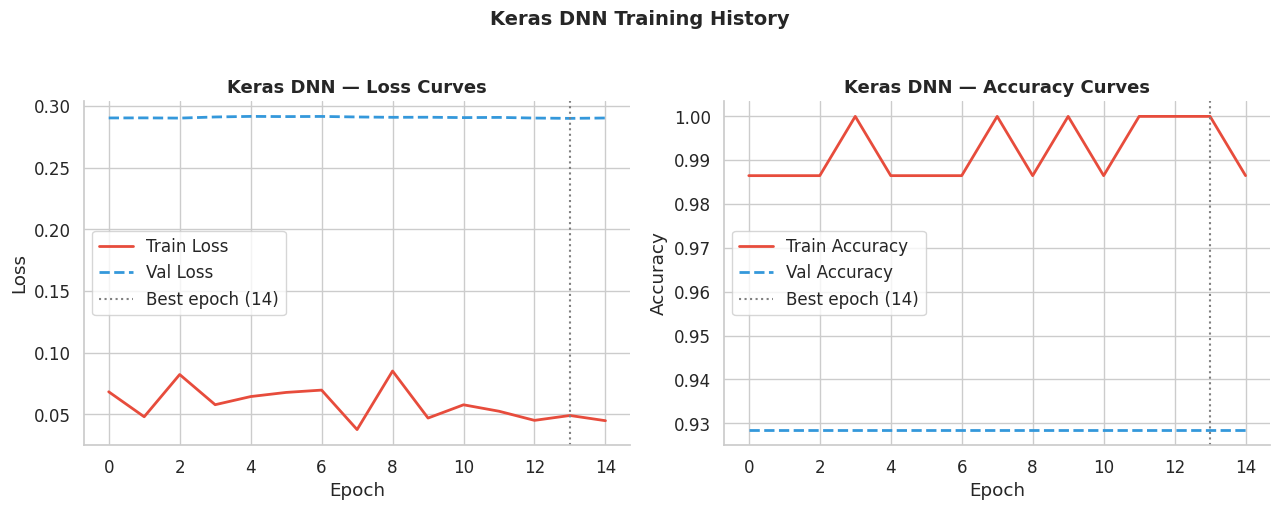

In [18]:
# Training curves
hist = keras_history.history
epochs_ran = len(hist['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Loss
ax1.plot(hist['loss'],     color='#e74c3c', lw=2, label='Train Loss')
ax1.plot(hist['val_loss'], color='#3498db', lw=2, label='Val Loss', linestyle='--')
ax1.axvline(best_epoch-1, color='gray', linestyle=':', lw=1.5, label=f'Best epoch ({best_epoch})')
ax1.set_title('Keras DNN — Loss Curves', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.spines[['top','right']].set_visible(False)

# Accuracy
ax2.plot(hist['accuracy'],     color='#e74c3c', lw=2, label='Train Accuracy')
ax2.plot(hist['val_accuracy'], color='#3498db', lw=2, label='Val Accuracy', linestyle='--')
ax2.axvline(best_epoch-1, color='gray', linestyle=':', lw=1.5, label=f'Best epoch ({best_epoch})')
ax2.set_title('Keras DNN — Accuracy Curves', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Keras DNN Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('keras_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

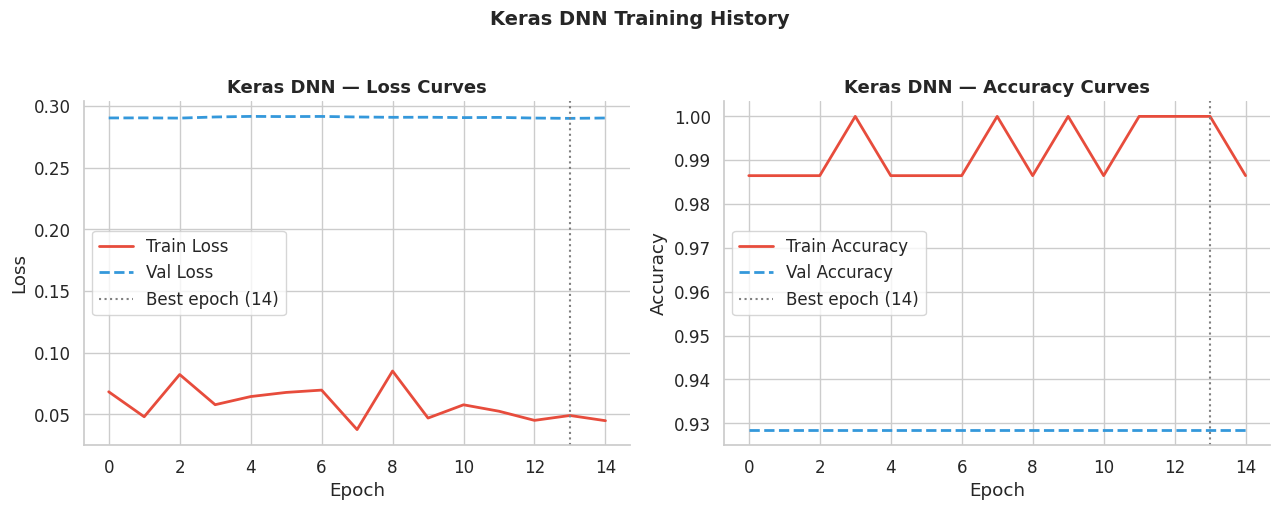

In [19]:
epochs_ran = len(hist['loss'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Loss
ax1.plot(hist['loss'],     color='#e74c3c', lw=2, label='Train Loss')
ax1.plot(hist['val_loss'], color='#3498db', lw=2, label='Val Loss', linestyle='--')
ax1.axvline(best_epoch-1, color='gray', linestyle=':', lw=1.5, label=f'Best epoch ({best_epoch})')
ax1.set_title('Keras DNN — Loss Curves', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.spines[['top','right']].set_visible(False)

# Accuracy
ax2.plot(hist['accuracy'],     color='#e74c3c', lw=2, label='Train Accuracy')
ax2.plot(hist['val_accuracy'], color='#3498db', lw=2, label='Val Accuracy', linestyle='--')
ax2.axvline(best_epoch-1, color='gray', linestyle=':', lw=1.5, label=f'Best epoch ({best_epoch})')
ax2.set_title('Keras DNN — Accuracy Curves', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Keras DNN Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('keras_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
keras_proba = keras_model.predict(X_test_sc, verbose=0)
keras_preds = np.argmax(keras_proba, axis=1)

keras_f1  = f1_score(y_test, keras_preds, average='macro')
keras_auc = roc_auc_score(
    label_binarize(y_test, classes=[0,1,2,3]),
    keras_proba, multi_class='ovr', average='macro'
)

print('Keras DNN Results:')
print(f'  Macro F1  : {keras_f1:.4f}')
print(f'  ROC-AUC   : {keras_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, keras_preds,
      target_names=SEV_ORDER, digits=4))

Keras DNN Results:
  Macro F1  : 0.1500
  ROC-AUC   : 0.5156

Classification Report:
              precision    recall  f1-score   support

        None     0.0000    0.0000    0.0000         1
        Mild     0.0000    0.0000    0.0000         1
    Moderate     0.7500    0.5000    0.6000         6
      Severe     0.0000    0.0000    0.0000         2

    accuracy                         0.3000        10
   macro avg     0.1875    0.1250    0.1500        10
weighted avg     0.4500    0.3000    0.3600        10



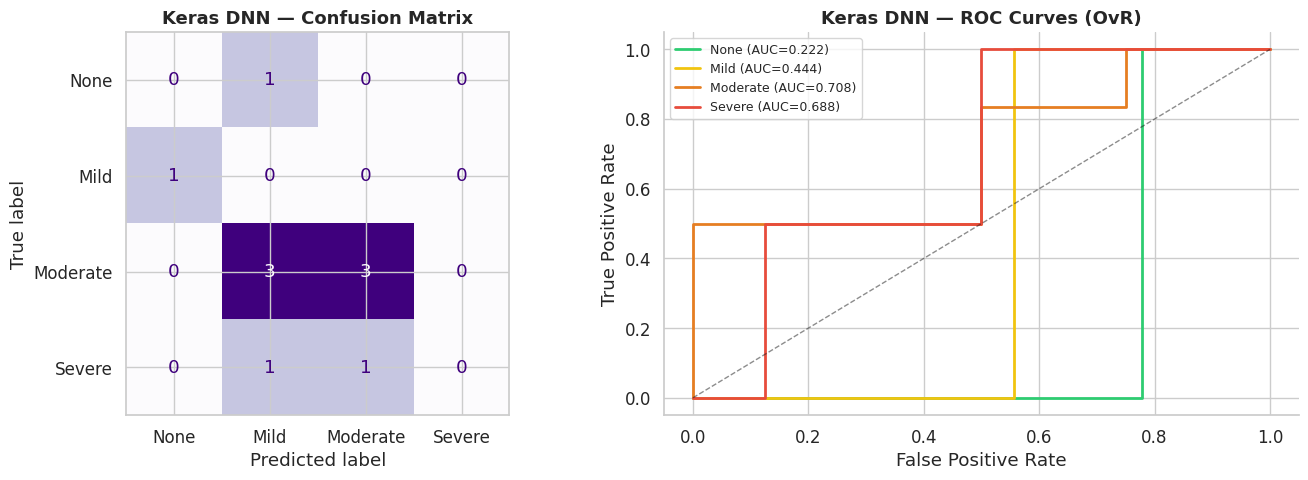

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, keras_preds),
    display_labels=SEV_ORDER).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Keras DNN — Confusion Matrix', fontsize=13, fontweight='bold')

# ROC curves overlaid on one plot
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
for i, (cls_name, color) in enumerate(zip(SEV_ORDER, SEV_COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], keras_proba[:,i])
    roc_val     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC={roc_val:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_title('Keras DNN — ROC Curves (OvR)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('keras_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
class DDIClassifier(nn.Module):
    """
    PyTorch DNN for DDI severity classification.
    Architecture mirrors the Keras model:
    Input -> Dense(256) -> BN -> ReLU -> Dropout
           -> Dense(128) -> BN -> ReLU -> Dropout
           -> Dense(64)  -> BN -> ReLU -> Dropout
           -> Dense(4) -> Softmax
    """
    def __init__(self, n_features, n_classes=4,
                 dropout_rates=(0.3, 0.25, 0.2)):
        super(DDIClassifier, self).__init__()

        self.block1 = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rates[0])
        )
        self.block2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rates[1])
        )
        self.block3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rates[2])
        )
        self.output = nn.Linear(64, n_classes)

        # Weight initialisation — He init for ReLU networks
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.output(x)  # raw logits — CrossEntropyLoss handles softmax

pt_model = DDIClassifier(n_features=N_FEATURES, n_classes=N_CLASSES).to(DEVICE)
print(pt_model)
total_params = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

DDIClassifier(
  (block1): Sequential(
    (0): Linear(in_features=31, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (block2): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=64, out_features=4, bias=True)
)

Trainable parameters: 50,500


In [23]:
# DataLoaders
def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y.values if hasattr(y,'values') else y, dtype=torch.long)
    ds  = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_tr,      y_tr,  batch_size=64, shuffle=True)
val_loader   = make_loader(X_val,     y_val, batch_size=128, shuffle=False)
test_loader  = make_loader(X_test_sc, y_test, batch_size=128, shuffle=False)

# Class weights for CrossEntropyLoss
from sklearn.utils.class_weight import compute_class_weight
cls_w  = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
cls_wt = torch.tensor(cls_w, dtype=torch.float32).to(DEVICE)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=cls_wt)
optimizer = optim.Adam(pt_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Class weights : {dict(zip(SEV_ORDER, [round(w,3) for w in cls_w]))}')

Train batches : 2
Val batches   : 1
Class weights : {'None': np.float64(1.028), 'Mild': np.float64(0.974), 'Moderate': np.float64(1.028), 'Severe': np.float64(0.974)}


In [24]:
# Custom training loop
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        preds       = logits.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits  = model(X_batch)
            loss    = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


print('Training functions defined.')

Training functions defined.


In [25]:
# Training loop with early stopping
EPOCHS        = 150
PATIENCE      = 15
PT_CKPT       = os.path.join(MODELS_FOLDER, 'pytorch_dnn_best.pt')

pt_history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_loss  = float('inf')
patience_count = 0
best_epoch_pt  = 0

print(f'Training PyTorch DNN on {DEVICE}...')
print(f'Max epochs: {EPOCHS} | Early stopping patience: {PATIENCE}\n')

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(pt_model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc = eval_epoch(pt_model,  val_loader,   criterion, DEVICE)
    scheduler.step()

    pt_history['train_loss'].append(tr_loss)
    pt_history['val_loss'].append(vl_loss)
    pt_history['train_acc'].append(tr_acc)
    pt_history['val_acc'].append(vl_acc)

    # Early stopping
    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_epoch_pt  = epoch
        patience_count = 0
        torch.save(pt_model.state_dict(), PT_CKPT)
    else:
        patience_count += 1

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f} | '
              f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.3f} | '
              f'LR: {lr_now:.2e}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (patience={PATIENCE})')
        break

# Reload best weights
pt_model.load_state_dict(torch.load(PT_CKPT, map_location=DEVICE))
print(f'\nBest epoch    : {best_epoch_pt}')
print(f'Best val loss : {best_val_loss:.4f}')

Training PyTorch DNN on cpu...
Max epochs: 150 | Early stopping patience: 15

Epoch   1/150 | Train Loss: 1.6596  Acc: 0.297 | Val Loss: 1.7311  Acc: 0.143 | LR: 1.00e-03
Epoch  10/150 | Train Loss: 0.7758  Acc: 0.689 | Val Loss: 0.6435  Acc: 0.786 | LR: 1.00e-03
Epoch  20/150 | Train Loss: 0.5622  Acc: 0.865 | Val Loss: 0.5416  Acc: 0.714 | LR: 5.00e-04
Epoch  30/150 | Train Loss: 0.4051  Acc: 0.892 | Val Loss: 0.5349  Acc: 0.786 | LR: 5.00e-04
Epoch  40/150 | Train Loss: 0.3662  Acc: 0.919 | Val Loss: 0.4897  Acc: 0.857 | LR: 2.50e-04
Epoch  50/150 | Train Loss: 0.3539  Acc: 0.905 | Val Loss: 0.4662  Acc: 0.857 | LR: 2.50e-04
Epoch  60/150 | Train Loss: 0.3262  Acc: 0.946 | Val Loss: 0.4309  Acc: 0.929 | LR: 1.25e-04
Epoch  70/150 | Train Loss: 0.3669  Acc: 0.919 | Val Loss: 0.4399  Acc: 0.929 | LR: 1.25e-04

Early stopping at epoch 72 (patience=15)

Best epoch    : 57
Best val loss : 0.4091


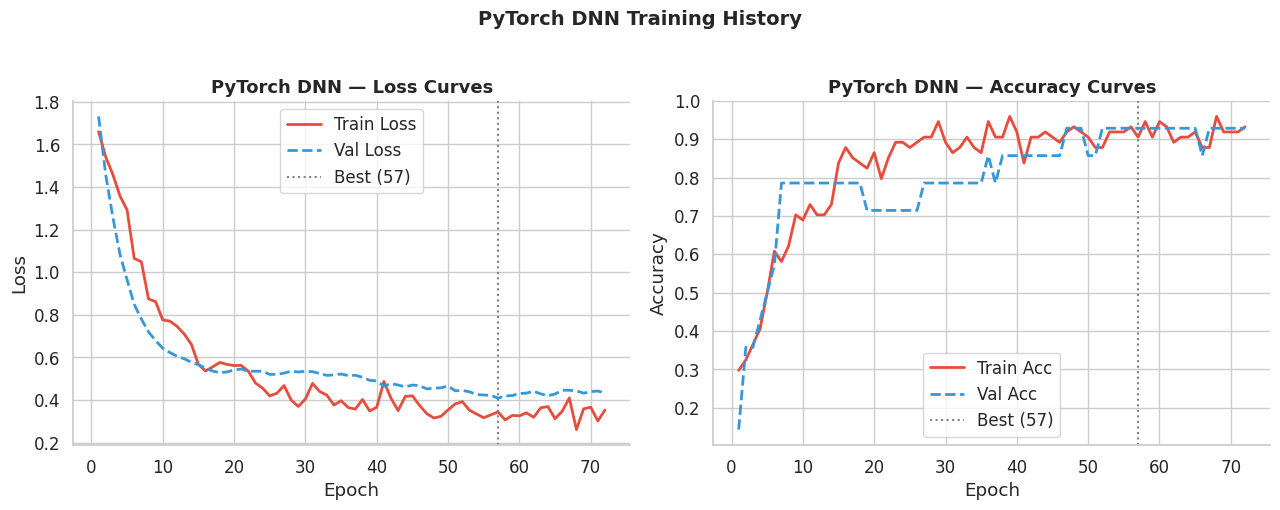

In [26]:
# PyTorch training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_arr = range(1, len(pt_history['train_loss']) + 1)

ax1.plot(epochs_arr, pt_history['train_loss'], color='#e74c3c', lw=2, label='Train Loss')
ax1.plot(epochs_arr, pt_history['val_loss'],   color='#3498db', lw=2, label='Val Loss', linestyle='--')
ax1.axvline(best_epoch_pt, color='gray', linestyle=':', lw=1.5, label=f'Best ({best_epoch_pt})')
ax1.set_title('PyTorch DNN — Loss Curves', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)

ax2.plot(epochs_arr, pt_history['train_acc'], color='#e74c3c', lw=2, label='Train Acc')
ax2.plot(epochs_arr, pt_history['val_acc'],   color='#3498db', lw=2, label='Val Acc', linestyle='--')
ax2.axvline(best_epoch_pt, color='gray', linestyle=':', lw=1.5, label=f'Best ({best_epoch_pt})')
ax2.set_title('PyTorch DNN — Accuracy Curves', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)

plt.suptitle('PyTorch DNN Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pytorch_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Get predictions on test set
pt_model.eval()
all_preds, all_proba = [], []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = pt_model(X_batch)
        proba   = torch.softmax(logits, dim=1)
        preds   = proba.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_proba.extend(proba.cpu().numpy())

pt_preds = np.array(all_preds)
pt_proba = np.array(all_proba)

pt_f1  = f1_score(y_test, pt_preds, average='macro')
pt_auc = roc_auc_score(
    label_binarize(y_test, classes=[0,1,2,3]),
    pt_proba, multi_class='ovr', average='macro'
)

print('PyTorch DNN Results:')
print(f'  Macro F1  : {pt_f1:.4f}')
print(f'  ROC-AUC   : {pt_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, pt_preds,
      target_names=SEV_ORDER, digits=4))

PyTorch DNN Results:
  Macro F1  : 0.1500
  ROC-AUC   : 0.4774

Classification Report:
              precision    recall  f1-score   support

        None     0.0000    0.0000    0.0000         1
        Mild     0.0000    0.0000    0.0000         1
    Moderate     0.7500    0.5000    0.6000         6
      Severe     0.0000    0.0000    0.0000         2

    accuracy                         0.3000        10
   macro avg     0.1875    0.1250    0.1500        10
weighted avg     0.4500    0.3000    0.3600        10



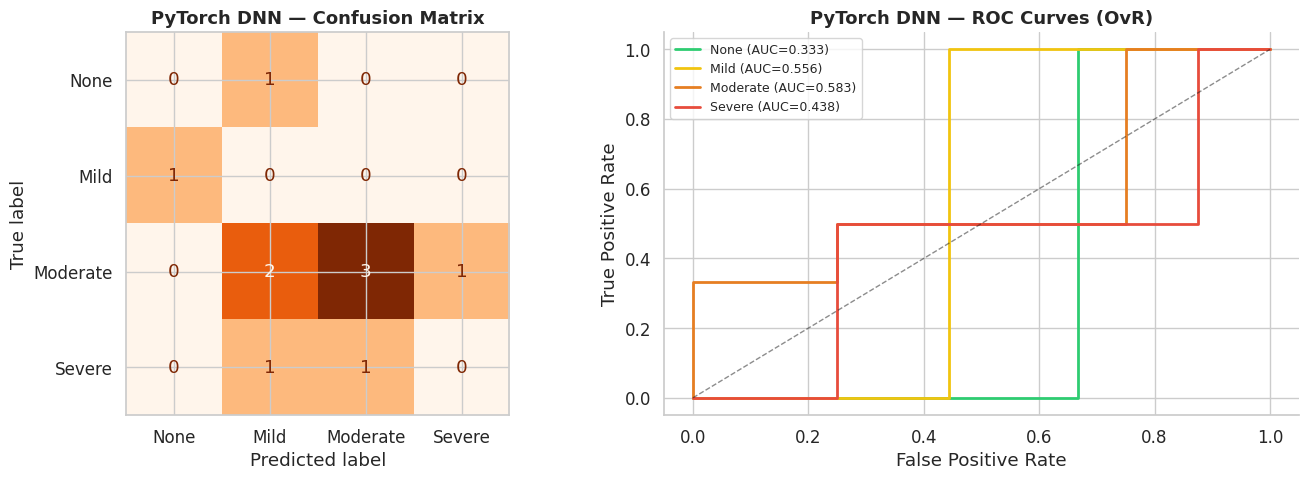

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, pt_preds),
    display_labels=SEV_ORDER).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('PyTorch DNN — Confusion Matrix', fontsize=13, fontweight='bold')

# ROC curves
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
for i, (cls_name, color) in enumerate(zip(SEV_ORDER, SEV_COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], pt_proba[:,i])
    roc_val     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC={roc_val:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[1].set_title('PyTorch DNN — ROC Curves (OvR)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('pytorch_validation.png', dpi=150, bbox_inches='tight')
plt.show()

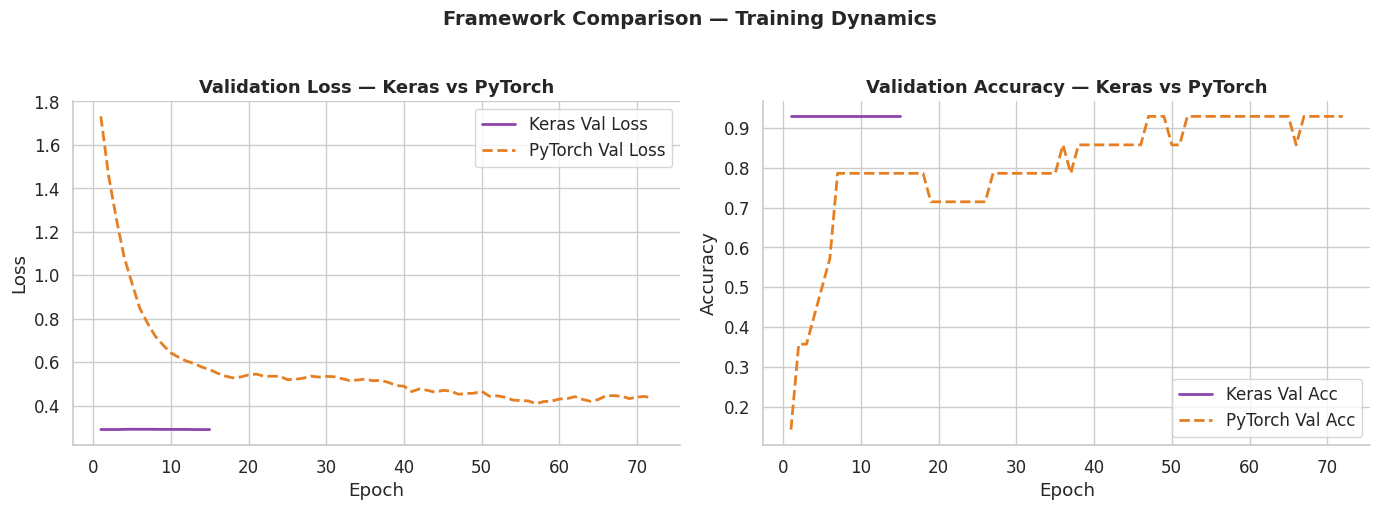

In [29]:
# Overlay training loss curves — Keras vs PyTorch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_epochs = range(1, len(hist['val_loss'])+1)
p_epochs = range(1, len(pt_history['val_loss'])+1)

# Val Loss comparison
axes[0].plot(k_epochs, hist['val_loss'],          color='#8e44ad', lw=2, label='Keras Val Loss')
axes[0].plot(p_epochs, pt_history['val_loss'],    color='#e67e22', lw=2, label='PyTorch Val Loss', linestyle='--')
axes[0].set_title('Validation Loss — Keras vs PyTorch', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# Val Accuracy comparison
axes[1].plot(k_epochs, hist['val_accuracy'],      color='#8e44ad', lw=2, label='Keras Val Acc')
axes[1].plot(p_epochs, pt_history['val_acc'],     color='#e67e22', lw=2, label='PyTorch Val Acc', linestyle='--')
axes[1].set_title('Validation Accuracy — Keras vs PyTorch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Framework Comparison — Training Dynamics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('framework_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

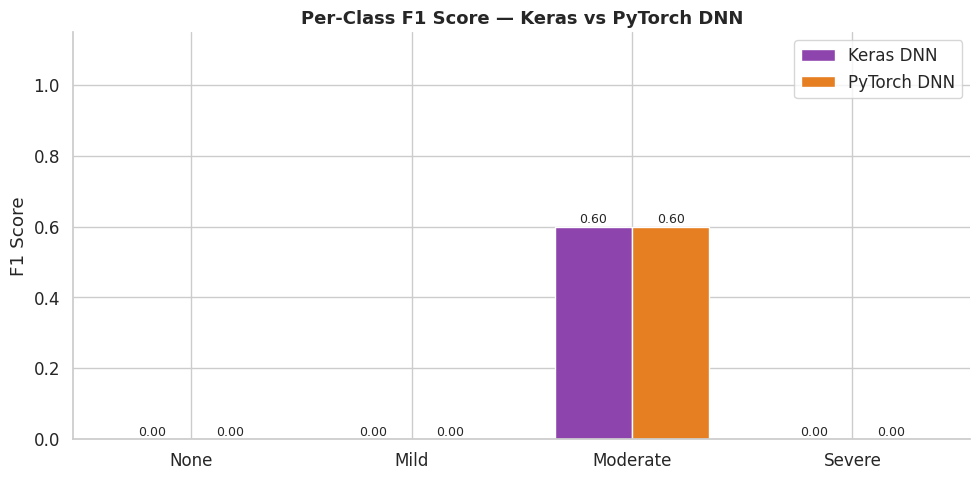

In [30]:
# Per-class F1 — Keras vs PyTorch side by side
def per_class_f1(y_true, y_pred):
    from sklearn.metrics import classification_report
    r = classification_report(y_true, y_pred, target_names=SEV_ORDER, output_dict=True)
    return [r[cls]['f1-score'] for cls in SEV_ORDER if cls in r]

keras_class_f1 = per_class_f1(y_test, keras_preds)
pt_class_f1    = per_class_f1(y_test, pt_preds)

x     = np.arange(len(SEV_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, keras_class_f1, width, label='Keras DNN',
               color='#8e44ad', edgecolor='white')
bars2 = ax.bar(x + width/2, pt_class_f1,    width, label='PyTorch DNN',
               color='#e67e22', edgecolor='white')

for bar, v in zip(list(bars1)+list(bars2), keras_class_f1+pt_class_f1):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.2f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(SEV_ORDER)
ax.set_title('Per-Class F1 Score — Keras vs PyTorch DNN', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('dl_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Load ML leaderboard from Notebook 02 (if available)
ml_lb_path = os.path.join(SAVE_FOLDER, 'ml_leaderboard.csv')

dl_rows = [
    {'Model':'Keras DNN',   'Macro F1':round(keras_f1,4),
     'ROC-AUC':round(keras_auc,4), 'CV F1 Mean':'-', 'CV F1 Std':'-',
     'Role':'Deep Learning (TF/Keras)'},
    {'Model':'PyTorch DNN', 'Macro F1':round(pt_f1,4),
     'ROC-AUC':round(pt_auc,4), 'CV F1 Mean':'-', 'CV F1 Std':'-',
     'Role':'Deep Learning (PyTorch)'},
]

if os.path.exists(ml_lb_path):
    ml_lb      = pd.read_csv(ml_lb_path)
    final_lb   = pd.concat([ml_lb, pd.DataFrame(dl_rows)], ignore_index=True)
    print('ML leaderboard loaded from Drive.')
else:
    print('ML leaderboard not found. Showing DL results only.')
    final_lb = pd.DataFrame(dl_rows)

# Sort by Macro F1
final_lb['F1_sort'] = pd.to_numeric(final_lb['Macro F1'], errors='coerce')
final_lb = final_lb.sort_values('F1_sort', ascending=False).drop(columns='F1_sort')
final_lb.index = range(1, len(final_lb)+1)

print('\n' + '='*72)
print('  FINAL MODEL LEADERBOARD — Nigeria DDI Classifier')
print('='*72)
print(final_lb.to_string())
print('='*72)

ML leaderboard loaded from Drive.

  FINAL MODEL LEADERBOARD — Nigeria DDI Classifier
                 Model  Macro F1  ROC-AUC CV F1 Mean CV F1 Std                      Role
1  Logistic Regression    0.1818   0.6146      0.214     0.088                  Baseline
2          PyTorch DNN    0.1500   0.4774          -         -   Deep Learning (PyTorch)
3            Keras DNN    0.1500   0.5156          -         -  Deep Learning (TF/Keras)
4        Random Forest    0.1250   0.3108     0.1587    0.0168                  Ensemble
5      XGBoost (Tuned)    0.0500   0.3438     0.1627    0.0744          Primary ML Model


In [32]:
# Final leaderboard Plotly bar chart
numeric_lb = final_lb[pd.to_numeric(final_lb['Macro F1'], errors='coerce').notna()].copy()
numeric_lb['Macro F1'] = pd.to_numeric(numeric_lb['Macro F1'])
numeric_lb['ROC-AUC']  = pd.to_numeric(numeric_lb['ROC-AUC'])

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Macro F1', x=numeric_lb['Model'], y=numeric_lb['Macro F1'],
    marker_color='#3498db', text=numeric_lb['Macro F1'].round(4), textposition='outside'
))
fig.add_trace(go.Bar(
    name='ROC-AUC', x=numeric_lb['Model'], y=numeric_lb['ROC-AUC'],
    marker_color='#e67e22', text=numeric_lb['ROC-AUC'].round(4), textposition='outside'
))
fig.update_layout(
    barmode='group',
    title='Final Leaderboard — All 5 Models (Nigeria DDI Classifier)',
    yaxis=dict(title='Score', range=[0,1.15]),
    xaxis_title='Model',
    plot_bgcolor='white',
    height=500,
    legend=dict(orientation='h', y=1.05)
)
fig.show()

In [33]:
# Summary observations
best_model = final_lb.iloc[0]['Model']
best_f1    = final_lb.iloc[0]['Macro F1']

print('KEY OBSERVATIONS')
print('='*55)
print(f'  Best overall model : {best_model}')
print(f'  Best Macro F1      : {best_f1}')
print()
print('  Keras DNN')
print(f'    Macro F1  : {keras_f1:.4f}')
print(f'    ROC-AUC   : {keras_auc:.4f}')
print(f'    Best epoch: {best_epoch}')
print()
print('  PyTorch DNN')
print(f'    Macro F1  : {pt_f1:.4f}')
print(f'    ROC-AUC   : {pt_auc:.4f}')
print(f'    Best epoch: {best_epoch_pt}')
print()
print('  Recommendation for Streamlit app:')
print(f'    -> Deploy {best_model} as primary inference model')
print('='*55)

KEY OBSERVATIONS
  Best overall model : Logistic Regression
  Best Macro F1      : 0.1818

  Keras DNN
    Macro F1  : 0.1500
    ROC-AUC   : 0.5156
    Best epoch: 14

  PyTorch DNN
    Macro F1  : 0.1500
    ROC-AUC   : 0.4774
    Best epoch: 57

  Recommendation for Streamlit app:
    -> Deploy Logistic Regression as primary inference model


In [35]:
# Keras model — two formats
keras_model.save(os.path.join(MODELS_FOLDER, 'keras_dnn.h5'))
keras_model.export(os.path.join(MODELS_FOLDER, 'keras_dnn_savedmodel'))

# PyTorch — state dict (best weights already saved during training)
# Also save full model for convenience
torch.save({
    'model_state_dict' : pt_model.state_dict(),
    'n_features'       : N_FEATURES,
    'n_classes'        : N_CLASSES,
    'feature_cols'     : FEATURE_COLS,
    'best_epoch'       : best_epoch_pt,
    'best_val_loss'    : best_val_loss,
    'pt_f1'            : pt_f1,
    'pt_auc'           : pt_auc,
}, os.path.join(MODELS_FOLDER, 'pytorch_dnn_full.pt'))

# Scaler & imputer (needed for Streamlit app inference)
joblib.dump(scaler,  os.path.join(MODELS_FOLDER, 'scaler_dl.pkl'))
joblib.dump(imputer, os.path.join(MODELS_FOLDER, 'imputer_dl.pkl'))

# Final leaderboard
final_lb.to_csv(os.path.join(SAVE_FOLDER, 'final_leaderboard.csv'), index=False)

# Training histories
pd.DataFrame(keras_history.history).to_csv(
    os.path.join(SAVE_FOLDER, 'keras_training_history.csv'), index=False)
pd.DataFrame(pt_history).to_csv(
    os.path.join(SAVE_FOLDER, 'pytorch_training_history.csv'), index=False)

print('Saved to Google Drive:')
print(f'  {MODELS_FOLDER}/keras_dnn.h5')
print(f'  {MODELS_FOLDER}/keras_dnn_savedmodel/')
print(f'  {MODELS_FOLDER}/pytorch_dnn_best.pt')
print(f'  {MODELS_FOLDER}/pytorch_dnn_full.pt')
print(f'  {MODELS_FOLDER}/scaler_dl.pkl')
print(f'  {MODELS_FOLDER}/imputer_dl.pkl')
print(f'  {SAVE_FOLDER}/final_leaderboard.csv')
print(f'  {SAVE_FOLDER}/keras_training_history.csv')
print(f'  {SAVE_FOLDER}/pytorch_training_history.csv')
print()
print('All done! Next: build streamlit_app.py')

Saved artifact at '/content/drive/MyDrive/DDI project /models/keras_dnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 31), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133360247401232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247399696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247402768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247401040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247399888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247403728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247402384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247402576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247402960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133360247403536: TensorSpec(shape=(), dtype=tf.res